# MESSAGEix-Pakistan 
## Baseline Model
   In this notebook, we are reading data and building baseline scenerios. Data was prepared using different script which we run in this notebook and solve our model. This script also generate some plots and resultant data.

<img src="https://wit.lums.edu.pk/sites/default/files/inline-images/WIT_Banner.jpg" alt="Girl in a jacket" width="850" height="250">

In [1]:
# Import required Libraries 
import pandas as pd
import ixmp
import message_ix
from message_ix import make_df
import os

# for modefiles execuation
import matplotlib.pyplot as plt
import pyam
import pandas as pd 
from ixmp import Platform
from ixmp.reporting import configure
from message_ix.reporting import Reporter
from pathlib import Path

# Import required files
from modelFiles.plotter_pakistan import plot, plotter
from modelFiles.demands import demands
from modelFiles.Update_historical_activity import historical_activity
from modelFiles.update_elec_share import new_tech_type_for_share, shares
from modelFiles.adjust_electricity_generation import adjust_electricity
from modelFiles.adjust_renewable_potential import adjust_renewable_potential_and_capacity
# Report Libraries
from message_ix.reporting import Reporter
#from modelFiles.update_units import unit_correction
from modelFiles.update_units_pakistan import unit_correction
import numpy as np

%matplotlib inline

<IPython.core.display.Javascript object>

In [2]:
# Loading Modeling platform
mp = ixmp.Platform()

In [3]:
# Creating a new, empty scenario
#use this only the first time
#scenario = message_ix.Scenario(
#    mp, model="COMMITTED", scenario="CurPol-rev", version="new"
#)

#for all the alterations in a sceanrio, clone the original scenario and add comments, make changes accordingly
model = "COMMITTED"
base = message_ix.Scenario(mp, model=model, scenario="CurPol-rev")
scenario = base.clone(
    model, "adjusting emissions", "illustration of adjusting GHG emissions", keep_solution=False
)
scenario.check_out()

While loading data, It's very important to pass aditional parameters like "init_items=True" in order to initialize items in a scenario with default values otherwise it will give some error.

In [4]:
# Add your project root folder path
# Make sure to adjust the root folder path
root = os.chdir(r"C:\Users\jouda\OneDrive\Documents\COMMITTED\CurPol")
path = "modelData/data_MESSAGE_PK.xlsx"
# Load data into our model - Current latest Data file is 
scenario.read_excel(path, add_units=True, commit_steps=False, init_items=True)

Cannot read set 'is_capacity_factor': index set(s) cannot be inferred for name(s) ['node_loc', 'year_act', 'year_vtg']


#### Correct Units
We use unit_correction function from modelFiles/update_units

In [5]:
unit_correct = True  # unit s must be corrected to run this script
from_excel = False
min_year = 2020
max_year = 2060

if unit_correct:
    unit_correction(mp, scenario)

 Notice: after this unit correction, you will have erorrs/issues if you use "old reporting" scripts!
- Unit was corrected for:
demand
resource_remaining
resource_volume
technical_lifetime
capacity_factor
inv_cost
fix_cost
var_cost
abs_cost_activity_soft_up
abs_cost_activity_soft_lo
level_cost_activity_soft_up
level_cost_activity_soft_lo
soft_activity_up
soft_activity_lo
resource_cost
output
input
initial_new_capacity_up
initial_new_capacity_lo
growth_new_capacity_up
growth_new_capacity_lo
initial_activity_up
initial_activity_lo
growth_activity_up
growth_activity_lo
construction_time
renewable_potential
renewable_capacity_factor
emission_scaling
relation_cost
relation_activity
duration_period
duration_time
interestrate
historical_new_capacity
historical_activity
MERtoPPP
aeei
cost_MESSAGE
demand_MESSAGE
depr
drate
esub
gdp_calibrate
grow
kgdp
kpvs
lakl
lotol
prfconst
price_MESSAGE
- Units were corrected.


In [6]:
catsss= scenario.set('cat_year')
print(catsss)

         type_year  year
0   firstmodelyear  2025
1    lastmodelyear  2060
2       cumulative  2020
3             2020  2020
4       cumulative  2025
5             2025  2025
6       cumulative  2030
7             2030  2030
8       cumulative  2035
9             2035  2035
10      cumulative  2040
11            2040  2040
12      cumulative  2045
13            2045  2045
14      cumulative  2050
15            2050  2050
16      cumulative  2055
17            2055  2055
18      cumulative  2060
19            2060  2060


### Adjust Renewable Potetial in model
In our intial file renewable portial for hydro is missing, Use below function to adjust renewable potential and renewable capacity factor in the model

In [7]:
adjust_renewable_potential_and_capacity(scenario)

### Adjust demands

Downscale regional demands to current pakistan GDP and Population profile

In [8]:
ssp = 'SSP2'
path = os.getcwd()
demands(scenario, path  + "\modelData" , ssp)

c:\Users\jouda\OneDrive\Documents\COMMITTED\CurPol\modelFiles\demands.py:187: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  oe = msgSC.par( 'output', {
c:\Users\jouda\OneDrive\Documents\COMMITTED\CurPol\modelFiles\demands.py:208: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  dm = ha.loc[ha['year_act']==dff.year.iloc[ind]].groupby('node_loc').sum().reset_index()
c:\Users\jouda\OneDrive\Documents\COMMITTED\CurPol\modelFiles\demands.py:292: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stabl

-- Demands are updated --


c:\Users\jouda\OneDrive\Documents\COMMITTED\CurPol\modelFiles\downscale_demands.py:67: OptimizeWarning: Unknown solver options: tol
  res = linprog(
c:\Users\jouda\OneDrive\Documents\COMMITTED\CurPol\modelFiles\demands.py:292: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dff.value.iloc[ind] = dm.value.to_numpy()[0]
c:\Users\jouda\OneDrive\Documents\COMMITTED\CurPol\modelFiles\demands.py:187: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  oe = msgSC.par( 'output', {
c:\Users\jouda\OneDrive\Documents\COMMITTED\CurPol\modelFiles\demands.py:208: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum

### Add Percentage share for electricity generation technologies

In order to adjust electricity generation values in model we start with adjust renewables shares in model particular for powerplants

In [9]:
# First we define new tecnology type in model to seperate all technologies related to power plants
suffix = '_PAK' 
nodeName = 'Pakistan'
new_tech_type_for_share(path  + "\modelData", scenario, suffix)
shares(scenario, path  + "\modelData", nodeName, suffix)

### Adjust Electricity generation 
The motivation to run this script is to adjust our electricity generation output generated from model

In [10]:
adjust_electricity(scenario)

-- Hydro Adjusted --
-- Solar Adjusted --
-- Bio Adjusted --
-- Coal Adjusted --


c:\Users\jouda\OneDrive\Documents\COMMITTED\CurPol\modelFiles\adjust_electricity_generation.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  coal_adv['value'] = coal_adv['value'] *1/100
c:\Users\jouda\OneDrive\Documents\COMMITTED\CurPol\modelFiles\adjust_electricity_generation.py:29: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  coal = coal_adv.append(coal_ppl)


-- Wind Adjusted --
-- Gas Adjusted --
-- Nuclear Adjusted --
Great !! End
adjustedddd
oil doneeee


In [11]:
from modelFiles.emissions_taxes import tax_emissions
tax_emissions(scenario, nodeName)

from modelFiles.update_transport import adjust_transport
adjust_transport(scenario)

from modelFiles.update_transport_share import new_tech_type_for_transport_share,shares_eth_trp,shares_elec_trp
new_tech_type_for_transport_share(path  + "\modelData", scenario, suffix)
#shares_eth_trp(scenario, path  + "\modelData", nodeName, suffix)
shares_elec_trp(scenario, path  + "\modelData", nodeName, suffix)

mp.add_unit("MtCO2")
from modelFiles.emissions_bound import bound_emissions
bound_emissions(scenario, nodeName)


-- Hydro Adjusted --
['elec_trp', 'eth_ic_trp', 'loil_trp', 'gas_trp', 'coal_trp', 'eth_fc_trp', 'foil_trp']


In [12]:
#scenario.check_out()
from message_ix import log

log.info(f"version number before commit(): {scenario.version}")

# Commit changes into the database checked
scenario.commit(comment="Add all data from excel file to scenario")
scenario.set_as_default()

# Exporting the built model (Scenario) to GAMS with an optional case name
caseName = scenario.model + '__' + scenario.scenario + '__v' + str(scenario.version)

# Solve model
scenario.solve(case=caseName)

scenario.var("OBJ")["lvl"]

41717.05859375

## Postprocessing and ploting results

In [13]:
from modelFiles.plotter_pakistan import plot, plotter
# Define
path = r"output"

alldf = plotter(scenario, caseName, path)

c:\Users\jouda\OneDrive\Documents\COMMITTED\CurPol\modelFiles\plotter_pakistan.py:79: FutureWarning: In a future version of pandas all arguments of DataFrame.pivot will be keyword-only.
  ppl_cap = ppl_cap.pivot('year_act', 'technology')
c:\Users\jouda\OneDrive\Documents\COMMITTED\CurPol\modelFiles\plotter_pakistan.py:88: FutureWarning: In a future version of pandas all arguments of DataFrame.pivot will be keyword-only.
  ppl_cap_new = ppl_cap_new.pivot('year_vtg', 'technology')
c:\Users\jouda\OneDrive\Documents\COMMITTED\CurPol\modelFiles\plotter_pakistan.py:96: FutureWarning: In a future version of pandas all arguments of DataFrame.pivot will be keyword-only.
  ppl_cap_hist = ppl_cap_hist.pivot('year_vtg', 'technology')
c:\Users\jouda\OneDrive\Documents\COMMITTED\CurPol\modelFiles\postprocess.py:45: FutureWarning: In a future version of pandas all arguments of DataFrame.pivot will be keyword-only.
  inputs = inputs.pivot('year_act', 'technology')
c:\Users\jouda\OneDrive\Documents\COM

In [14]:
# 2) Then Run Plot function
plot(alldf, caseName, path)

Axes(0.125,0.11;0.465x0.462)
Axes(0.125,0.11;0.465x0.462)
Axes(0.125,0.11;0.465x0.462)
Axes(0.125,0.11;0.465x0.462)
Axes(0.125,0.11;0.465x0.462)
Axes(0.125,0.11;0.465x0.462)
Axes(0.125,0.11;0.465x0.462)
Axes(0.125,0.11;0.465x0.462)
Axes(0.125,0.11;0.465x0.462)
Axes(0.125,0.11;0.465x0.462)
Axes(0.125,0.11;0.465x0.462)
Axes(0.125,0.11;0.62x0.462)
Axes(0.125,0.11;0.465x0.462)
Axes(0.125,0.11;0.465x0.462)
Axes(0.125,0.11;0.465x0.462)
Axes(0.125,0.11;0.465x0.462)
Axes(0.125,0.11;0.465x0.462)
Axes(0.125,0.11;0.465x0.462)
Axes(0.125,0.11;0.465x0.462)
Axes(0.125,0.11;0.465x0.462)
Axes(0.125,0.11;0.465x0.462)
Axes(0.125,0.11;0.465x0.462)
Axes(0.125,0.11;0.465x0.462)


c:\Users\jouda\OneDrive\Documents\COMMITTED\CurPol\modelFiles\plotter_pakistan.py:497: FutureWarning: save is not part of the public API, usage can give unexpected results and will be removed in a future version
  writer_xls.save()


### Report 2

Make Areal graphs for (Demand by sector, CO2 Emissions, Primary energy supply by fuel, and total operation cost) on model output data

1) Plot for Primary Energy by fuel - Baseline Scenario

2) Plot for demands by sector

3. Plot for CO2 Emissions - Baseline Scenario

4. Plot for Total (Operational + Investment) Costs - Baseline

emission_factor: mixed units ['tC', '???', 'kg/kWa'] discarded
c:\Users\jouda\OneDrive\Documents\COMMITTED\CurPol\modelFiles\reporter.py:48: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  all_flows = out_flows.append(in_flows)
pyam - INFO: Running in a notebook, setting up a basic logging at level INFO
pyam.utils - WARNING: Formatted data is empty!
pyam.utils - WARNING: Formatted data is empty!
pyam.utils - WARNING: Formatted data is empty!
pyam.utils - WARNING: Formatted data is empty!
pyam.utils - WARNING: Formatted data is empty!
pyam.utils - WARNING: Formatted data is empty!


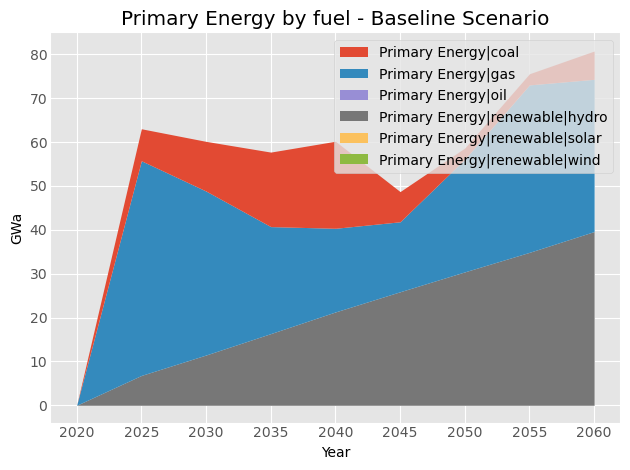

pyam.core - WARNING: Filtered IamDataFrame is empty!


IndexError: positional indexers are out-of-bounds

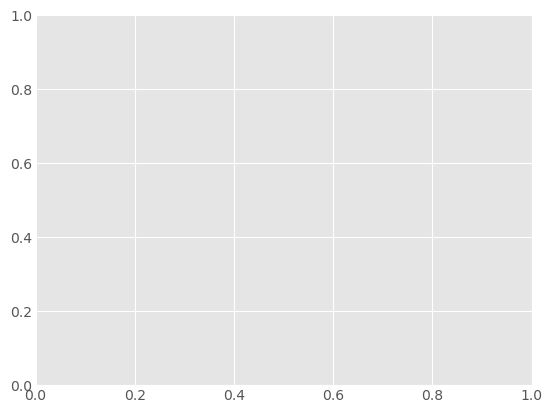

In [15]:
from modelFiles.reporter import get_report_df, primary_energy_by_fuel_plot, demand_by_sector_plot, emission_plots, operation_investment_cost_plot

df = get_report_df(scenario)

primary_energy_by_fuel_plot(df)
demand_by_sector_plot(df)
emission_plots(df)
operation_investment_cost_plot(df)

In [ ]:
# closed the database connection, you can reopen it using "mp.open_db()"
mp.close_db()